# **Análisis Financiero de Datos y Diseño de Indicadores**

**Instrucciones:**
- Este examen utiliza el método del caso para evaluar tu comprensión de los KPIs y su rol en la toma de decisiones. 
- En cada pregunta, _explica claramente tu razonamiento_ y muestra todos los cálculos necesarios.
- Puedes utilizar Python (Pandas, Matplotlib, Seaborn) para los cálculos y visualizaciones.
- Sé conciso y directo en tus explicaciones.

## **Criterios de Evaluación:**
- **Subsección 1** (10 puntos): Capacidad de tomar decisiones sobre datos NULL. 
- **Subsección 2** (20 puntos): Exactitud en los cálculos de KPIs, agrupaciones correctas y gráficos acertados. Lo más importante, es saber qué inferir y **qué no inferir** sobre los datos obtenidos. 
- **Subsección 3** (40 puntos): Aplicación correcta del método IQR. Además, saber por qué usar IQR, y de nuevo, saber qué inferir y **qué no inferir** sobre los datos obtenidos. 
- **Subsección 4** (35 puntos): Calidad de las recomendaciones, profundidad del razonamiento y comprensión del impacto en la estrategia futura.

---
## **Estudio de Caso: Fintech Company**

El presupuesto de adquisición de clientes de la mayoría de las compañías es limitado y por ello es **muy importante** saber en qué **segmento** de clientes concentrar el Marketing.

Una de las métricas que te permite saber esto es `LTV / CAC`. 

A ti te toca saber a qué segmento de clientes escoger. 

La empresa te proporciona los siguientes datos **por cliente**:

- **Customer_ID**: ID del cliente
- **Age**: Edad
- **Location**: Ubicación del cliente
- **Income_Level**: Nivel de ingreso
- **Total_Transactions**: Total de transacciones
- **Avg_Transaction_Value**: Promedio de transacción
- **Total_Spent**: Total transaccionado
- **Active_Days**: Número de días que ha tenido actividad con algún producto financiero
- **Last_Transaction_Days_Ago**: Número de días desde última transacción
- **Loyalty_Points_Earned**: Total de puntos de lealtad
- **Referral_Count**: Número de clientes referidos
- **Cashback_Received**: Cashback recibido por el cliente
- **App_Usage_Frequency**: Frecuencia de uso de la app
- **Preferred_Payment_Method**: Método de pago preferido
- **Support_Tickets_Raised**: Total de tickets de soporte al cliente
- **Issue_Resolution_Time**: Tiempo de resolución de tickets en horas totales
- **Customer_Satisfaction_Score**: Score de satisfacción del cliente
- **Customer_Acquisition_Cost**: Costo de adquisición del cliente (CAC)
- **LTV**: Estimación del valor total del cliente
---

----

### Subsección 1
El dataset contiene datos NULL. 
1. De acuerdo con lo visto en la clase decide qué hacer con ellos: 
   - Retirarlos
   - Imputarlos
2. ¿Por qué tomaste esa decisión?
----
### Subsección 2
1. Calcula el `LTV / CAC`
2. Realiza una agrupación por edad del cliente: 
   - "Joven": 18 a 30 años
   - "Adulto": 30 a 40 años
   - "Adulto Maduro": 40 a 60 años
   - "Senior": Mayor de 60 años
3. Haz dos gráficas de `boxplot`:
   - Una debe mostrar el `LTV / CAC` por grupos de edad
   - Otra debe mostrar el `LTV / CAC` por `Income_Level`
4. Responde, ¿qué observas en ambas gráficas?, ¿qué conclusiones se obtienen?
----
### Subsección 3
Tienes un número alto de _outliers_ en tu columna de `LTV / CAC`.

Utiliza el método de IQR con k = 3 para identificarlos; estas son las fórmulas: 

- $\text{IQR} = \text{Q3-Q1}$
- $\text{Upper Bound} = \text{Q3 + (3 * IQR)}$
- $\text{Lower Bound} = \text{Q1 - (3 * IQR)}$

Outliers son los valores menores al `Lower Bound` o mayores al `Upper Bound`.

1. Identifica dentro de tu dataset a los outliers de la columna `LTV / CAC`.
2. ¿Cuántos outliers hay?
3. Remueve los outliers. 
4. Ahora, **SIN OUTLIERS** haz de nuevo las dos gráficas de `boxplot`:
   - `LTV / CAC` por grupos de edad
   - `LTV / CAC` por `Income_Level`
5. Obtén conclusiones a partir de estas gráficas: 
   - ¿A qué segmento de clientes conviene enfocarse?, ¿por qué?
   - ¿Por qué usar el LTV/CAC?

-----

### Subsección 4 

Te interesa incrementar aún más el `LTV / CAC`.

1. Obtén la matriz de correlación.
2. Propón estrategias para aumentar el `LTV / CAC`.

---

In [53]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

customer_df = pd.read_csv('data/fintech_data.csv')

In [54]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   Customer_ID                  1000 non-null   object 
 2   Age                          1000 non-null   int64  
 3   Location                     1000 non-null   object 
 4   Income_Level                 963 non-null    object 
 5   Total_Transactions           1000 non-null   int64  
 6   Avg_Transaction_Value        1000 non-null   float64
 7   Total_Spent                  1000 non-null   float64
 8   Active_Days                  1000 non-null   int64  
 9   Last_Transaction_Days_Ago    1000 non-null   int64  
 10  Loyalty_Points_Earned        1000 non-null   int64  
 11  Referral_Count               1000 non-null   int64  
 12  Cashback_Received            1000 non-null   float64
 13  App_Usage_Frequency

### Subsección 1

In [55]:
mode_income_level = customer_df['Income_Level'].mode()[0]

In [56]:
customer_df['Income_Level'] = customer_df['Income_Level'].fillna(mode_income_level)

In [57]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   Customer_ID                  1000 non-null   object 
 2   Age                          1000 non-null   int64  
 3   Location                     1000 non-null   object 
 4   Income_Level                 1000 non-null   object 
 5   Total_Transactions           1000 non-null   int64  
 6   Avg_Transaction_Value        1000 non-null   float64
 7   Total_Spent                  1000 non-null   float64
 8   Active_Days                  1000 non-null   int64  
 9   Last_Transaction_Days_Ago    1000 non-null   int64  
 10  Loyalty_Points_Earned        1000 non-null   int64  
 11  Referral_Count               1000 non-null   int64  
 12  Cashback_Received            1000 non-null   float64
 13  App_Usage_Frequency

### Subsección 2

In [59]:
# cálculo de LTV / CAC
customer_df['ltv_cac'] = customer_df['LTV'] / customer_df['Customer_Acquisition_Cost']

In [60]:
# grupos de edad
customer_df['age_groups'] = pd.cut(customer_df['Age'], bins=[17,30,40,60,80], labels=["Joven","Adulto","Adulto Mayor","Senior"], right=True)

<Axes: xlabel='Income_Level', ylabel='ltv_cac'>

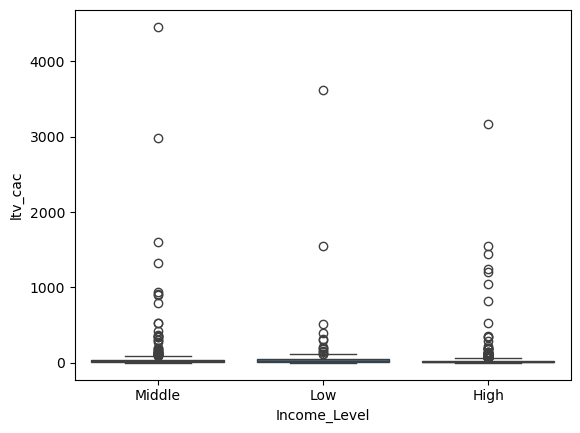

In [61]:
# gráfica de ltv/cac por income_level
sns.boxplot(data=customer_df, x="Income_Level",y="ltv_cac")

<Axes: xlabel='age_groups', ylabel='ltv_cac'>

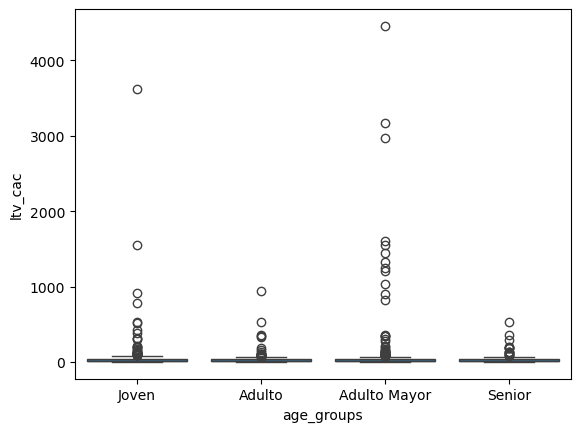

In [70]:
# gráfica de ltv/cac por grupos de edad
sns.boxplot(data=customer_df, x="age_groups",y="ltv_cac")

### Subsección 3

In [73]:
p25 = customer_df['ltv_cac'].quantile(0.25)
p75 = customer_df['ltv_cac'].quantile(0.75)

iqr = (p75 - p25) 

lower_bound = p25-(iqr*3)
upper_bound = p75+(iqr*3)

customer_df['ltv_cac_outlier'] = ((customer_df['ltv_cac'] < lower_bound) | (customer_df['ltv_cac'] > upper_bound))*1

In [75]:
customer_df['ltv_cac_outlier'].sum()

91

In [77]:
customer_df_no_outliers = customer_df[customer_df['ltv_cac_outlier'] == 0]

In [79]:
customer_df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Unnamed: 0                   909 non-null    int64   
 1   Customer_ID                  909 non-null    object  
 2   Age                          909 non-null    int64   
 3   Location                     909 non-null    object  
 4   Income_Level                 909 non-null    object  
 5   Total_Transactions           909 non-null    int64   
 6   Avg_Transaction_Value        909 non-null    float64 
 7   Total_Spent                  909 non-null    float64 
 8   Active_Days                  909 non-null    int64   
 9   Last_Transaction_Days_Ago    909 non-null    int64   
 10  Loyalty_Points_Earned        909 non-null    int64   
 11  Referral_Count               909 non-null    int64   
 12  Cashback_Received            909 non-null    float64 
 13  App_Usage_

<Axes: xlabel='Income_Level', ylabel='ltv_cac'>

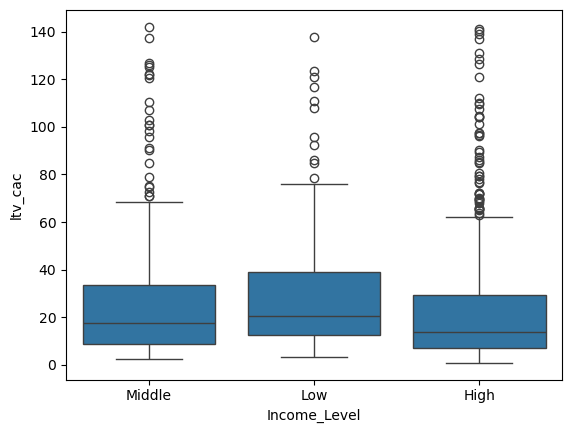

In [81]:
sns.boxplot(data=customer_df_no_outliers, x="Income_Level",y="ltv_cac")

<Axes: xlabel='age_groups', ylabel='ltv_cac'>

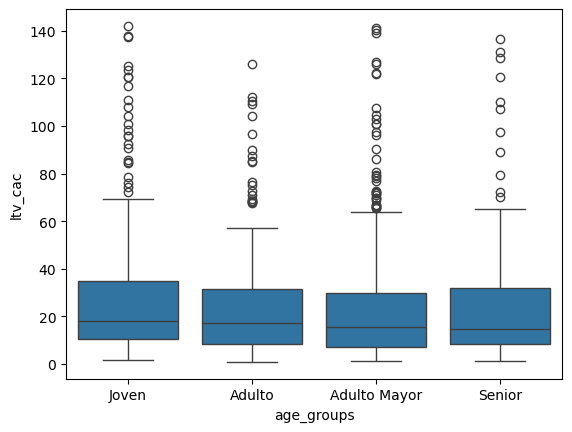

In [83]:
sns.boxplot(data=customer_df_no_outliers, x="age_groups",y="ltv_cac")

### Subsección 4

<Axes: >

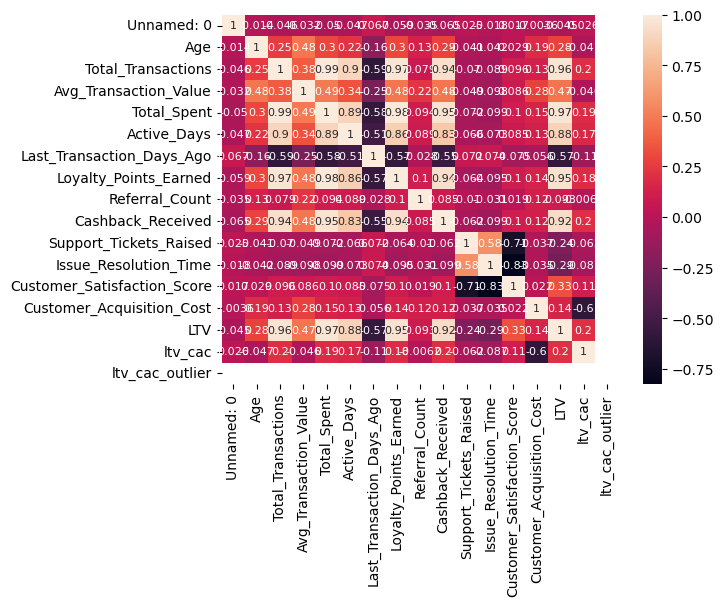

In [88]:
import numpy as np

correlation_matrix = customer_df_no_outliers.select_dtypes(include=[np.number]).corr()

sns.heatmap(correlation_matrix, annot=True, annot_kws={"size":8})